In [2]:
import copy

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch as th
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, confusion_matrix, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from torch import nn
from torch_geometric.nn import VGAE, GATConv, GCNConv, SAGEConv

In [ ]:
# Données générées par le notebook 0 (split train / val / test fait avec RandomLinkSplit)
train_data = th.load('../data/train_data_norm.pt', weights_only=False)
val_data = th.load('../data/val_data_norm.pt', weights_only=False)
test_data = th.load('../data/test_data_norm.pt', weights_only=False)
data = th.load('../data/data_norm.pt', weights_only=False)

print(test_data)
print(f"\nFeatures des nœuds : [longitude, latitude, population] -> {data.num_features} features")

# Paramètres communs à toutes les expériences
HIDDEN, DIM_OUT, EPOCHS, LR = 32, 16, 200, 0.01
SEEDS = [0, 1, 2]

Data(edge_index=[2, 21676], country=[3363], city_name=[3363], x=[3363, 216], pos_edge_label=[2709], pos_edge_label_index=[2, 2709], neg_edge_label=[2709], neg_edge_label_index=[2, 2709])

Features des nœuds : [longitude, latitude, population] -> 3 features


In [15]:
class Encoder(nn.Module):
    def __init__(self, dim_in, hidden_channels, dim_out, conv=GCNConv):
        super(Encoder, self).__init__()
        self.conv1 = conv(dim_in, hidden_channels)
        self.conv_mu = conv(hidden_channels, dim_out)
        self.conv_logstd = conv(hidden_channels, dim_out)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        mu = self.conv_mu(x, edge_index)
        logstd = self.conv_logstd(x, edge_index)
        return mu, logstd


def entrainer_et_tester(model, optimizer, epochs, train_data, val_data, test_data):
    history = {"train": [], "val": []}
    meilleure_auc_val, meilleur_etat = -1, None
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        z = model.encode(train_data.x, train_data.edge_index)
        loss = model.recon_loss(
            z, train_data.pos_edge_label_index, train_data.neg_edge_label_index
        ) + model.kl_loss() / train_data.num_nodes
        loss.backward()
        optimizer.step()
        history["train"].append(loss.item())

        # validation : pas de calcul de gradient
        model.eval()
        with th.no_grad():
            z_val = model.encode(val_data.x, val_data.edge_index)
            val_loss = model.recon_loss(
                z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index
            ) + model.kl_loss() / val_data.num_nodes
            history["val"].append(val_loss.item())
            auc_val, _ = model.test(z_val, val_data.pos_edge_label_index, val_data.neg_edge_label_index)
            if auc_val > meilleure_auc_val:
                meilleure_auc_val, meilleur_etat = auc_val, copy.deepcopy(model.state_dict())

    # évaluation sur le test avec le meilleur modèle (choisi sur la validation)
    model.load_state_dict(meilleur_etat)
    model.eval()
    with th.no_grad():
        z_test = model.encode(test_data.x, test_data.edge_index)
        auc_test, ap_test = model.test(z_test, test_data.pos_edge_label_index, test_data.neg_edge_label_index)
    return history, auc_test, ap_test


def lancer_experience(splits, conv=GCNConv, hidden_channels=HIDDEN, dim_out=DIM_OUT):
    # un entraînement par seed ; renvoie les résultats test, l'historique et le modèle de la première seed
    resultats, historique, modele = [], None, None
    for seed in SEEDS:
        th.manual_seed(seed)
        model = VGAE(Encoder(splits[0].num_features, hidden_channels, dim_out, conv))
        optimizer = th.optim.Adam(model.parameters(), lr=LR)
        history, auc, ap = entrainer_et_tester(model, optimizer, EPOCHS, *splits)
        resultats.append({"seed": seed, "AUC": auc, "AP": ap})
        if seed == SEEDS[0]:
            historique, modele = history, model
    return resultats, historique, modele

In [ ]:
splits_bruts = (train_data, val_data, test_data)
dimensions = {
    "model_a (32 → 16)": (32, 16),
    "model_b (128 → 16)": (128, 16),
    "model_c (6 → 6)": (6, 6),
}
EPOCHS=50
resultats_dim, historiques_dim, modeles_dim = [], {}, {}
for nom, (hidden_channels, dim_out) in dimensions.items():
    resultats, historiques_dim[nom], modeles_dim[nom] = lancer_experience(
        splits_bruts, GCNConv, hidden_channels, dim_out, EPOCHS=EPOCHS)
    resultats_dim += [{"modele": nom, **r} for r in resultats]
    print(f"{nom} : AUC test = " + ", ".join(f"{r['AUC']:.4f}" for r in resultats))



model_a (32 → 16) : AUC test = 0.9749, 0.9740, 0.9735
model_b (128 → 16) : AUC test = 0.9742, 0.9741, 0.9761
model_c (6 → 6) : AUC test = 0.9599, 0.9521, 0.9592


In [17]:
convs = {"GCN": GCNConv, "GAT": GATConv, "SAGE": SAGEConv}

resultats_convs, historiques_convs, modeles_convs = [], {}, {}
for nom, conv in convs.items():
    resultats, historiques_convs[nom], modeles_convs[nom] = lancer_experience(splits_bruts, conv)
    resultats_convs += [{"couche": nom, **r} for r in resultats]
    print(f"{nom} : AUC test = " + ", ".join(f"{r['AUC']:.4f}" for r in resultats))
    



GCN : AUC test = 0.9749, 0.9740, 0.9735
GAT : AUC test = 0.9339, 0.9346, 0.9348
SAGE : AUC test = 0.9290, 0.9336, 0.9322


In [13]:
print(modeles_convs)
print(modeles_dim)


from torch import save
# sauvegarde des modèles et des résultats , comment faire ?


save(modeles_convs, "../resultats/modeles_convs.pth")

save(modeles_dim, "../resultats/modeles_dim.pth")
save(resultats_convs, "../resultats/resultats_convs.pth")
save(resultats_dim, "../resultats/resultats_dim.pth")






{'GCN': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(3, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logstd): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
), 'GAT': VGAE(
  (encoder): Encoder(
    (conv1): GATConv(3, 32, heads=1)
    (conv_mu): GATConv(32, 16, heads=1)
    (conv_logstd): GATConv(32, 16, heads=1)
  )
  (decoder): InnerProductDecoder()
), 'SAGE': VGAE(
  (encoder): Encoder(
    (conv1): SAGEConv(3, 32, aggr=mean)
    (conv_mu): SAGEConv(32, 16, aggr=mean)
    (conv_logstd): SAGEConv(32, 16, aggr=mean)
  )
  (decoder): InnerProductDecoder()
)}
{'model_a (32 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(3, 32)
    (conv_mu): GCNConv(32, 16)
    (conv_logstd): GCNConv(32, 16)
  )
  (decoder): InnerProductDecoder()
), 'model_b (128 → 16)': VGAE(
  (encoder): Encoder(
    (conv1): GCNConv(3, 128)
    (conv_mu): GCNConv(128, 16)
    (conv_logstd): GCNConv(128, 16)
  )
  (decoder): InnerProductDecoder()
), 'model_c (6 → 6)': VGAE(
  (encoder): Encoder(


In [22]:
def resumer(df, colonnes):
    # moyenne et écart-type sur les seeds
    return df.groupby(colonnes, sort=False)[["AUC", "AP"]].agg(["mean", "std"]).round(4)


def tracer_barres(df, col_groupe, col_serie=None, titre="", ylim=(0.4, 1.03)):
    # barres AUC / AP (moyenne ± écart-type sur les seeds) + ligne de la baseline distance (section 1)
    if col_serie is None:
        df = df.assign(_serie="VGAE")
        col_serie = "_serie"
    stats = df.groupby([col_groupe, col_serie], sort=False)[["AUC", "AP"]].agg(["mean", "std"])
    groupes = list(dict.fromkeys(df[col_groupe]))
    series = list(dict.fromkeys(df[col_serie]))
    largeur = 0.8 / len(series)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
    for ax, metrique in zip(axes, ["AUC", "AP"]):
        for i, serie in enumerate(series):
            positions = [g + (i - (len(series) - 1) / 2) * largeur for g in range(len(groupes))]
            moyennes = [stats.loc[(g, serie), (metrique, "mean")] for g in groupes]
            ecarts = [stats.loc[(g, serie), (metrique, "std")] for g in groupes]
            barres = ax.bar(positions, moyennes, largeur, yerr=ecarts, capsize=3,
                            label=serie if col_serie != "_serie" else None)
            ax.bar_label(barres, fmt="%.3f", padding=3, fontsize=7)
        #ax.axhline(baseline[metrique], color="#c62828", linestyle="--", linewidth=1, label="baseline distance")
        ax.axhline(0.5, color="black", linestyle=":", linewidth=1, label="hasard")
        ax.set_xticks(range(len(groupes)), groupes)
        ax.set_ylim(*ylim)
        ax.set_title(f"{metrique} test — {titre}")
        ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=6, fontsize=8)
    plt.tight_layout()
    plt.show()


def tracer_loss(historiques, titre):
    # courbes de loss train (trait plein) et validation (pointillés), échelle log
    plt.figure(figsize=(8, 4))
    for nom, history in historiques.items():
        ligne, = plt.plot(history["train"], label=f"{nom} train")
        plt.plot(history["val"], linestyle="--", color=ligne.get_color(), label=f"{nom} val")
    plt.yscale("log")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (échelle log)")
    plt.title(titre)
    plt.legend(fontsize=8)
    plt.show()


def afficher_matrice_confusion(lemodele, donnees_testees, titre):
    # eval() met le modèle en mode évaluation, désactivant certaines fonctionnalités comme le dropout et la normalisation par lot qui ne sont utilisées que pendant l'entraînement.
    lemodele.eval()
    with th.no_grad():
        # Encodage des nœuds pour obtenir leurs représentations latentes.
        z = lemodele.encode(donnees_testees.x, donnees_testees.edge_index)

        # Récupération de toutes les arêtes positives et négatives
        pos_edges = donnees_testees.pos_edge_label_index
        neg_edges = donnees_testees.neg_edge_label_index
        edges = th.cat([pos_edges, neg_edges], dim=1)

        probabilites = lemodele.decode(z, edges, sigmoid=True)
        perf = lemodele.test(z, pos_edges, neg_edges)
        predictions = (probabilites >= 0.9).long().cpu().numpy()

        vrais_labels = th.cat([
            th.ones(pos_edges.size(1), dtype=th.long),
            th.zeros(neg_edges.size(1), dtype=th.long),
        ]).numpy()

    matrice = confusion_matrix(vrais_labels, predictions, labels=[0, 1])
    print(f"\nMatrice de confusion — {titre}")
    print("Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]")
    print(matrice)
    print(f"Perf : AUC {perf[0]:.4f} (vrai_positif/faux_positif) - AP {perf[1]:.4f} ( précision/rappel )")

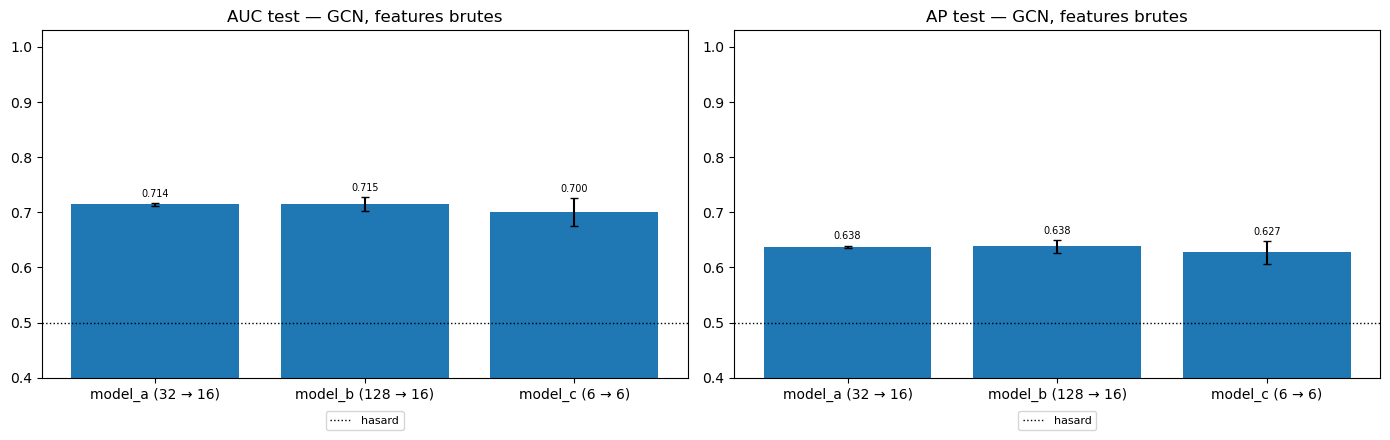

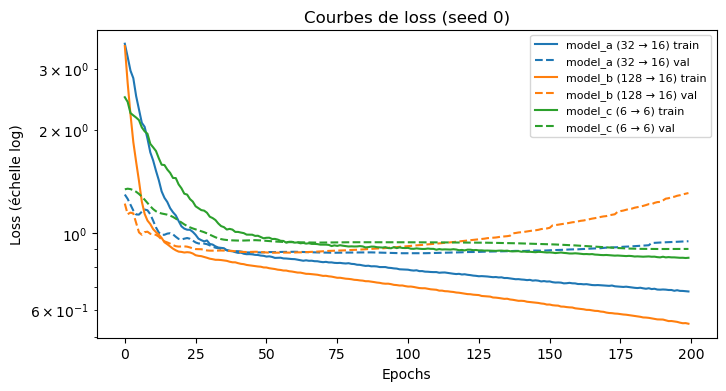


Matrice de confusion — model_a (32 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2656   53]
 [ 677 2032]]
Perf : AUC 0.9749 (vrai_positif/faux_positif) - AP 0.9760 ( précision/rappel )

Matrice de confusion — model_b (128 → 16) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2660   49]
 [ 698 2011]]
Perf : AUC 0.9742 (vrai_positif/faux_positif) - AP 0.9754 ( précision/rappel )

Matrice de confusion — model_c (6 → 6) test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2659   50]
 [ 950 1759]]
Perf : AUC 0.9599 (vrai_positif/faux_positif) - AP 0.9614 ( précision/rappel )


In [26]:
tracer_barres(df_dimensions, "modele", titre="GCN, features brutes")
tracer_loss(historiques_dim, "Courbes de loss (seed 0)")
for nom, model in modeles_dim.items():
    afficher_matrice_confusion(model, test_data, f"{nom} test_data")

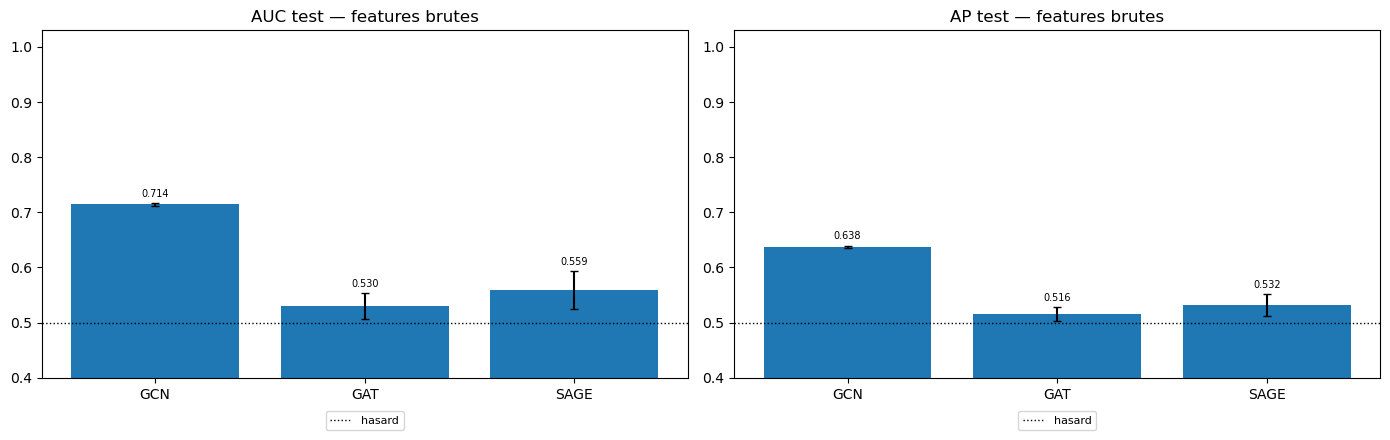

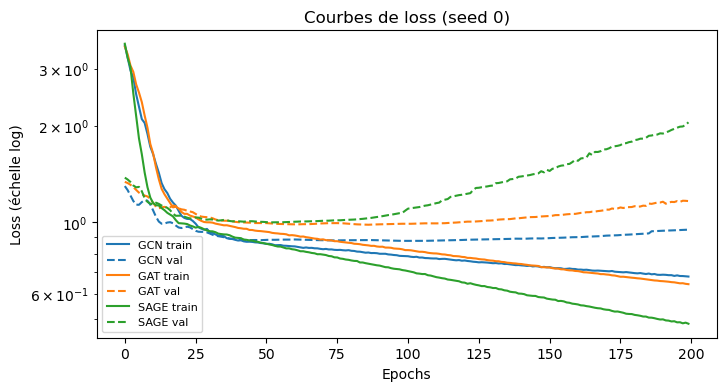


Matrice de confusion — GCN test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2656   53]
 [ 677 2032]]
Perf : AUC 0.9749 (vrai_positif/faux_positif) - AP 0.9760 ( précision/rappel )

Matrice de confusion — GAT test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2583  126]
 [ 917 1792]]
Perf : AUC 0.9339 (vrai_positif/faux_positif) - AP 0.9239 ( précision/rappel )

Matrice de confusion — SAGE test_data
Lignes : réel [non-arête, arête] ; colonnes : prédit [non-arête, arête]
[[2572  137]
 [ 889 1820]]
Perf : AUC 0.9290 (vrai_positif/faux_positif) - AP 0.9251 ( précision/rappel )


In [25]:
tracer_barres(df_convs, "couche", titre="features brutes")
tracer_loss(historiques_convs, "Courbes de loss (seed 0)")
for nom, model in modeles_convs.items():
    afficher_matrice_confusion(model, test_data, f"{nom} test_data")